In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for the notebook
sns.set_theme(style="whitegrid")

# 1. Load the data
# Replace 'insurance_data.csv' with your actual file name
df = pd.read_csv(r'C:\Users\HP\Desktop\10acadamey\insurance-risk-analytics\data\MachineLearningRating_v3.txt', sep='|')# 2. Convert date columns (assuming there is a policy date or claim date)
# df['EffectiveDate'] = pd.to_datetime(df['EffectiveDate'])

print("=== DATA TYPES & OVERVIEW ===")
print(df.info())

print("\n=== DESCRIPTIVE STATISTICS ===")
display(df.describe())

C:\Users\HP\AppData\Local\Temp\ipykernel_776\1205831405.py:11: DtypeWarning: Columns (32,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'C:\Users\HP\Desktop\10acadamey\insurance-risk-analytics\data\MachineLearningRating_v3.txt', sep='|')# 2. Convert date columns (assuming there is a policy date or claim date)


=== DATA TYPES & OVERVIEW ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   UnderwrittenCoverID       1000098 non-null  int64  
 1   PolicyID                  1000098 non-null  int64  
 2   TransactionMonth          1000098 non-null  object 
 3   IsVATRegistered           1000098 non-null  bool   
 4   Citizenship               1000098 non-null  object 
 5   LegalType                 1000098 non-null  object 
 6   Title                     1000098 non-null  object 
 7   Language                  1000098 non-null  object 
 8   Bank                      854137 non-null   object 
 9   AccountType               959866 non-null   object 
 10  MaritalStatus             991839 non-null   object 
 11  Gender                    990562 non-null   object 
 12  Country                   1000098 non-null  object 
 1

,UnderwrittenCoverID,PolicyID,PostalCode,mmcode,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,CustomValueEstimate,NumberOfVehiclesInFleet,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims
count,1.000098e+06,1.000098e+06,1.000098e+06,9.995460e+05,1.000098e+06,999546.000000,999546.000000,999546.000000,999546.000000,2.204560e+05,0.0,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06
mean,1.048175e+05,7.956682e+03,3.020601e+03,5.487770e+07,2.010225e+03,4.046642,2466.743258,97.207919,4.019250,2.255311e+05,NaN,6.041727e+05,1.178757e+02,6.190550e+01,6.486119e+01
std,6.329371e+04,5.290039e+03,2.649854e+03,1.360381e+07,3.261391e+00,0.294020,442.800640,19.393256,0.468314,5.645157e+05,NaN,1.508332e+06,3.997017e+02,2.302845e+02,2.384075e+03
min,1.000000e+00,1.400000e+01,1.000000e+00,4.041200e+06,1.987000e+03,0.000000,0.000000,0.000000,0.000000,2.000000e+04,NaN,1.000000e-02,0.000000e+00,-7.825768e+02,-1.200241e+04
25%,5.514300e+04,4.500000e+03,8.270000e+02,6.005692e+07,2.008000e+03,4.000000,2237.000000,75.000000,4.000000,1.350000e+05,NaN,5.000000e+03,3.224800e+00,0.000000e+00,0.000000e+00
50%,9.408300e+04,7.071000e+03,2.000000e+03,6.005842e+07,2.011000e+03,4.000000,2694.000000,111.000000,4.000000,2.200000e+05,NaN,7.500000e+03,8.436900e+00,2.178333e+00,0.000000e+00
75%,1.391900e+05,1.107700e+04,4.180000e+03,6.005842e+07,2.013000e+03,4.000000,2694.000000,111.000000,4.000000,2.800000e+05,NaN,2.500000e+05,9.000000e+01,2.192982e+01,0.000000e+00
max,3.011750e+05,2.324600e+04,9.870000e+03,6.506535e+07,2.015000e+03,10.000000,12880.000000,309.000000,6.000000,2.655000e+07,NaN,1.263620e+07,7.442217e+04,6.528260e+04,3.930921e+05


=== MISSING VALUES COUNT ===
Bank                        145961
AccountType                  40232
MaritalStatus                 8259
Gender                        9536
mmcode                         552
VehicleType                    552
make                           552
Model                          552
Cylinders                      552
cubiccapacity                  552
kilowatts                      552
bodytype                       552
NumberOfDoors                  552
VehicleIntroDate               552
CustomValueEstimate         779642
CapitalOutstanding               2
NewVehicle                  153295
WrittenOff                  641901
Rebuilt                     641901
Converted                   641901
CrossBorder                 999400
NumberOfVehiclesInFleet    1000098
dtype: int64


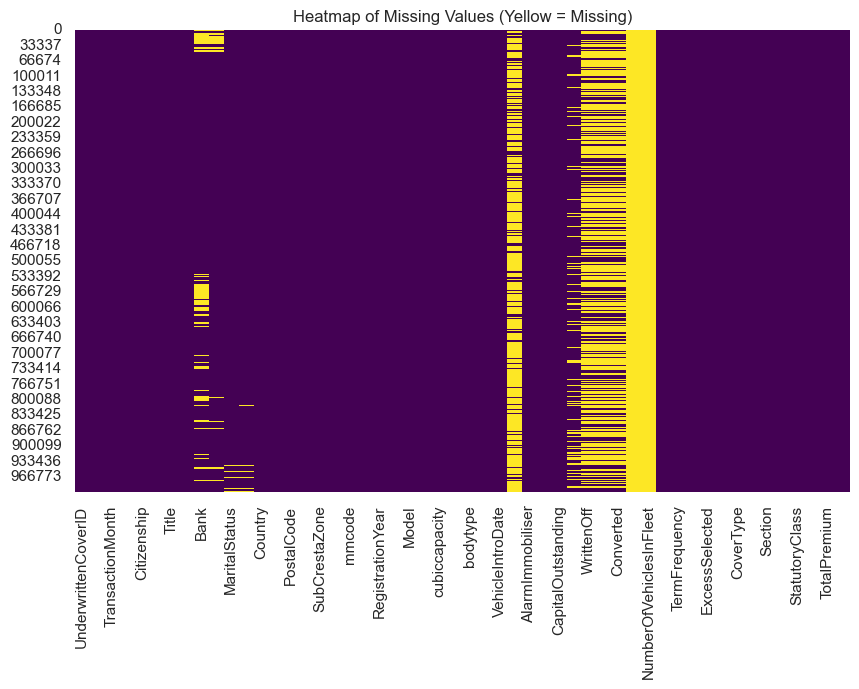

In [6]:
print("=== MISSING VALUES COUNT ===")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

# Visualize missing data locations
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values (Yellow = Missing)')
plt.show()

# Example Handling Strategy (Uncomment to use):
# 1. Drop rows where ZipCode is missing
# df.dropna(subset=['ZipCode'], inplace=True)
# 2. Fill missing premiums with the median
# df['TotalPremium'].fillna(df['TotalPremium'].median(), inplace=True)

In [11]:
print(df.columns.tolist())

['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium', 'TotalClaims']


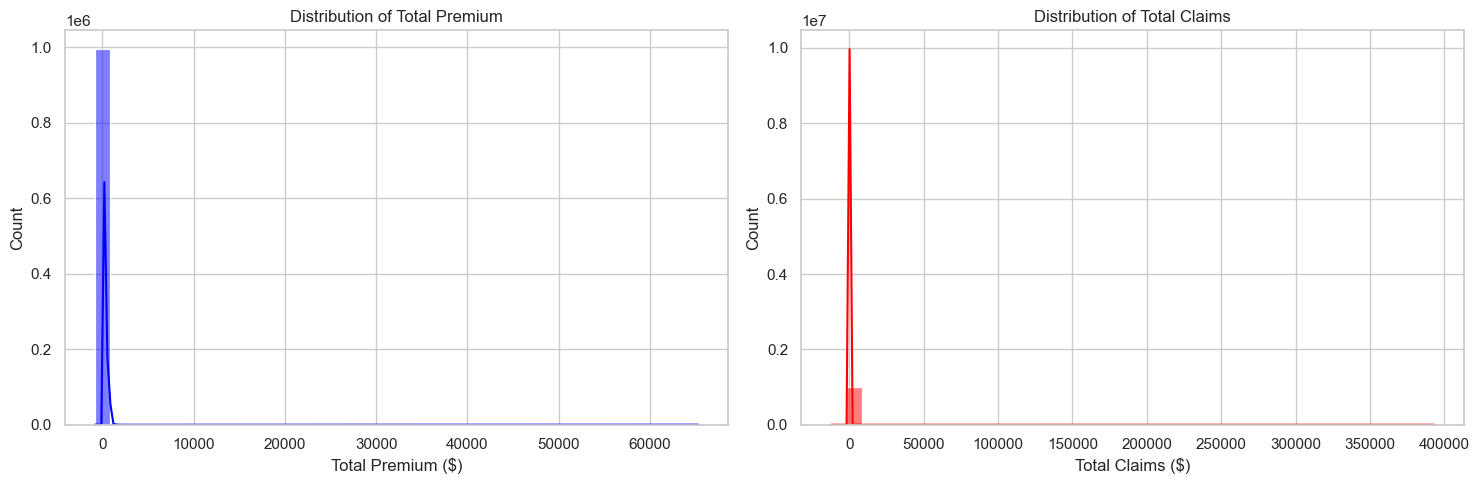

C:\Users\HP\AppData\Local\Temp\ipykernel_776\3807592400.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='CoverType', palette='Set2')


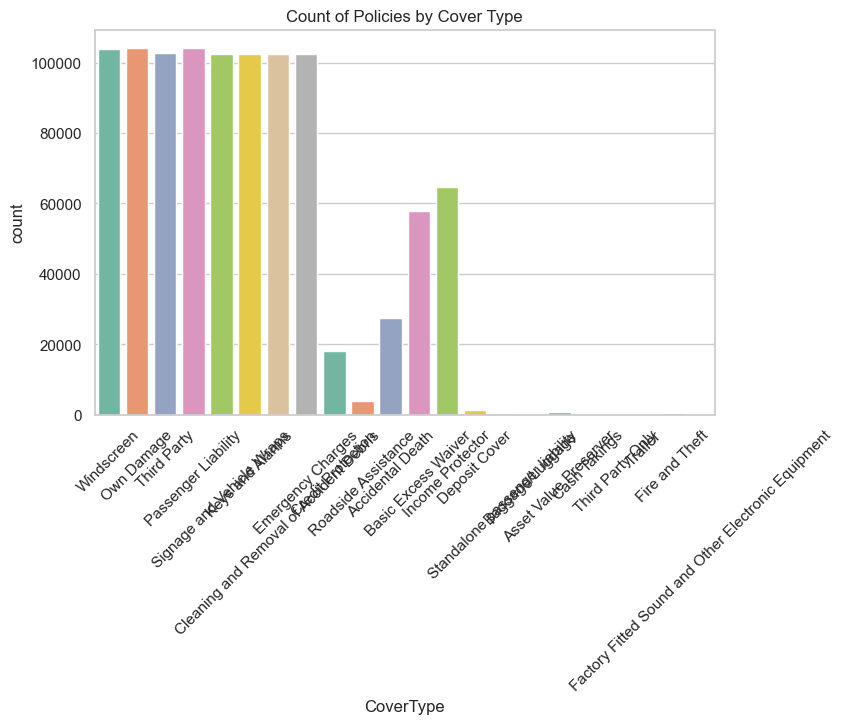

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Numerical: Histogram of TotalPremium
sns.histplot(df['TotalPremium'], bins=40, kde=True, color='blue', ax=axes[0])
axes[0].set_title('Distribution of Total Premium')
axes[0].set_xlabel('Total Premium ($)')

# 2. Numerical: Histogram of TotalClaims
sns.histplot(df['TotalClaims'], bins=40, kde=True, color='red', ax=axes[1])
axes[1].set_title('Distribution of Total Claims')
axes[1].set_xlabel('Total Claims ($)')

plt.tight_layout()
plt.show()

# 3. Categorical: Bar chart of Cover Type
plt.figure(figsize=(8, 5))
# ---> FIX IS HERE: Change 'CoverType' to match your exact column name <---
sns.countplot(data=df, x='CoverType', palette='Set2') 
plt.title('Count of Policies by Cover Type')
plt.xticks(rotation=45)
plt.show()

C:\Users\HP\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


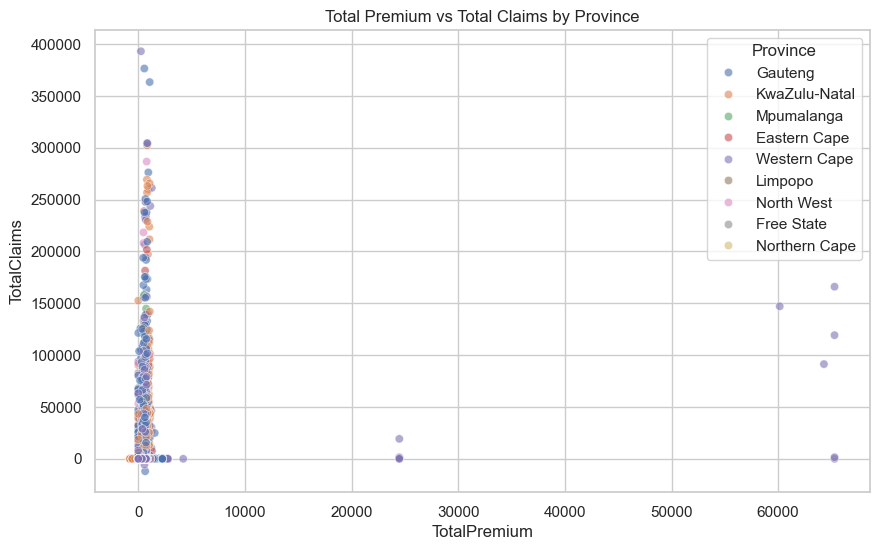

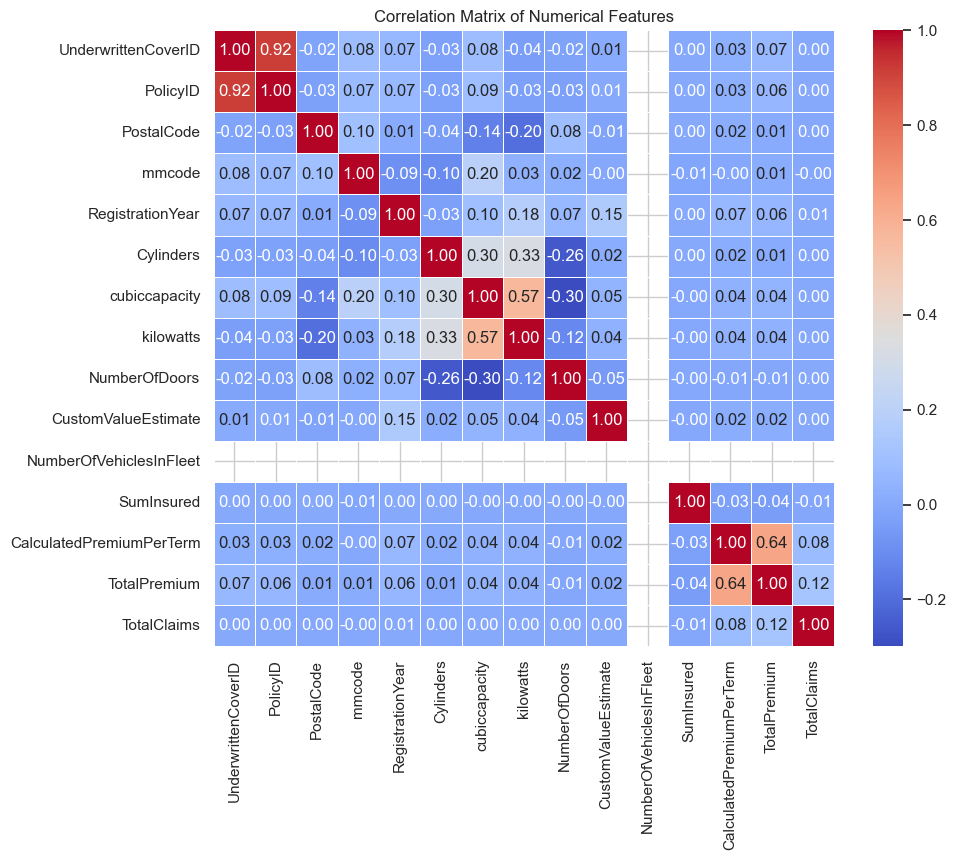

In [8]:
# 1. Scatter Plot: Premium vs Claims, colored by Province (or ZipCode)
plt.figure(figsize=(10, 6))
# If ZipCode has too many unique values, 'Province' is better for the hue color
sns.scatterplot(data=df, x='TotalPremium', y='TotalClaims', hue='Province', alpha=0.6)
plt.title('Total Premium vs Total Claims by Province')
plt.show()

# 2. Correlation Matrix
plt.figure(figsize=(10, 8))
# Select only numerical columns for correlation
numerical_df = df.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

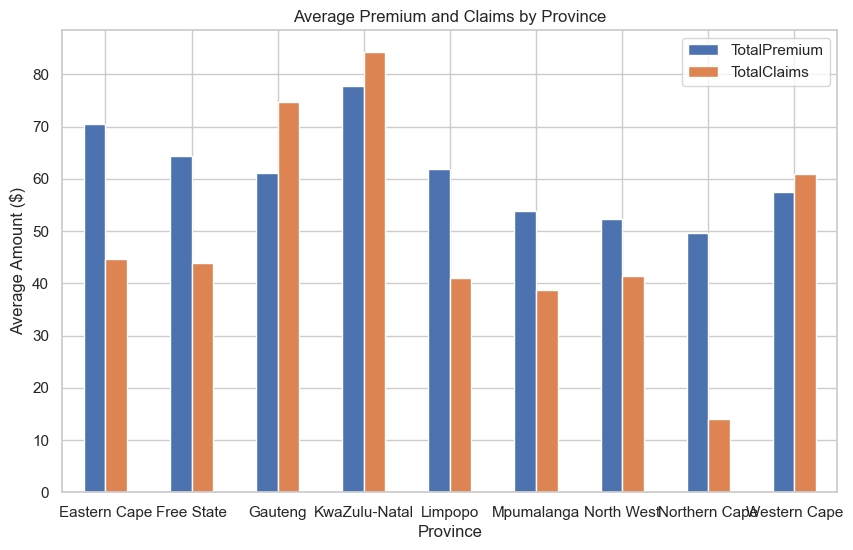

=== TOP AUTO MAKE PER PROVINCE ===
Province
Eastern Cape     TOYOTA
Free State       TOYOTA
Gauteng          TOYOTA
KwaZulu-Natal    TOYOTA
Limpopo          TOYOTA
Mpumalanga       TOYOTA
North West       TOYOTA
Northern Cape    TOYOTA
Western Cape     TOYOTA
Name: make, dtype: object


In [13]:
# 1. Average Premium and Claims by Province
geo_financials = df.groupby('Province')[['TotalPremium', 'TotalClaims']].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
geo_financials.plot(x='Province', y=['TotalPremium', 'TotalClaims'], kind='bar', ax=ax)
plt.title('Average Premium and Claims by Province')
plt.ylabel('Average Amount ($)')
plt.xticks(rotation=0)
plt.show()

# 2. Top Auto Make per Province
print("=== TOP AUTO MAKE PER PROVINCE ===")
# ---> FIX IS HERE: Change 'auto_make' to match your exact column name (e.g., 'make') <---
top_makes = df.groupby('Province')['make'].agg(lambda x: x.value_counts().index[0])
print(top_makes)

C:\Users\HP\AppData\Local\Temp\ipykernel_776\1272331626.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='TotalPremium', x='CoverType', ax=axes[0], palette='pastel')
C:\Users\HP\AppData\Local\Temp\ipykernel_776\1272331626.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='TotalClaims', x='CoverType', ax=axes[1], palette='pastel')


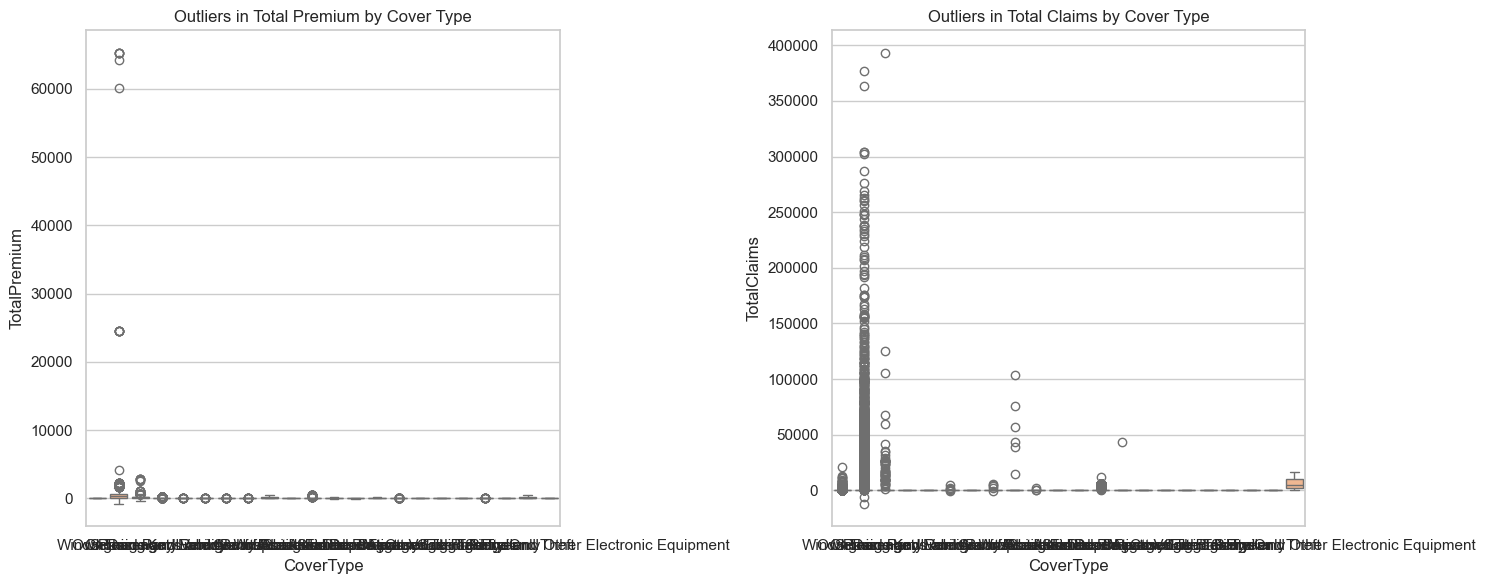

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot for Total Premium
# ---> FIX IS HERE: Change 'cover_type' to 'CoverType' <---
sns.boxplot(data=df, y='TotalPremium', x='CoverType', ax=axes[0], palette='pastel')
axes[0].set_title('Outliers in Total Premium by Cover Type')

# Boxplot for Total Claims
# ---> FIX IS HERE: Change 'cover_type' to 'CoverType' <---
sns.boxplot(data=df, y='TotalClaims', x='CoverType', ax=axes[1], palette='pastel')
axes[1].set_title('Outliers in Total Claims by Cover Type')

plt.tight_layout()
plt.show()

In [15]:
# Create a helper function to avoid writing the same code three times
def calculate_loss_ratio(df, category):
    # Group by the category and sum up premiums and claims
    grouped = df.groupby(category)[['TotalPremium', 'TotalClaims']].sum()
    # Calculate the ratio percentage
    grouped['Loss_Ratio_%'] = (grouped['TotalClaims'] / grouped['TotalPremium']) * 100
    # Sort from highest risk to lowest
    return grouped.sort_values(by='Loss_Ratio_%', ascending=False)

# 1. Overall Portfolio Loss Ratio
overall_ratio = (df['TotalClaims'].sum() / df['TotalPremium'].sum()) * 100
print(f"=== OVERALL PORTFOLIO LOSS RATIO: {overall_ratio:.2f}% ===\n")

# 2. Breakdowns (Ensure your column names match exactly: 'Province', 'VehicleType', 'Gender')
print("--- Loss Ratio by Province ---")
display(calculate_loss_ratio(df, 'Province').head())

print("\n--- Loss Ratio by Vehicle Type ---")
# Change 'VehicleType' if your dataset spells it differently!
display(calculate_loss_ratio(df, 'VehicleType').head())

print("\n--- Loss Ratio by Gender ---")
display(calculate_loss_ratio(df, 'Gender'))

=== OVERALL PORTFOLIO LOSS RATIO: 104.77% ===

--- Loss Ratio by Province ---


,TotalPremium,TotalClaims,Loss_Ratio_%
Province,,,
Gauteng,2.405377e+07,2.939415e+07,122.201812
KwaZulu-Natal,1.320908e+07,1.430138e+07,108.269332
Western Cape,9.806559e+06,1.038977e+07,105.947196
North West,7.490508e+06,5.920250e+06,79.036694
Mpumalanga,2.836292e+06,2.044675e+06,72.089735



--- Loss Ratio by Vehicle Type ---


,TotalPremium,TotalClaims,Loss_Ratio_%
VehicleType,,,
Heavy Commercial,4.609479e+05,7.504746e+05,162.811164
Medium Commercial,3.922746e+06,4.119867e+06,105.025086
Passenger Vehicle,5.664202e+07,5.937207e+07,104.819837
Light Commercial,2.604975e+05,6.045250e+04,23.206555
Bus,5.824474e+04,7.996535e+03,13.729197



--- Loss Ratio by Gender ---


,TotalPremium,TotalClaims,Loss_Ratio_%
Gender,,,
Not specified,5.920275e+07,6.271410e+07,105.931060
Male,1.580143e+06,1.396704e+06,88.390993
Female,3.044806e+05,2.502461e+05,82.187876


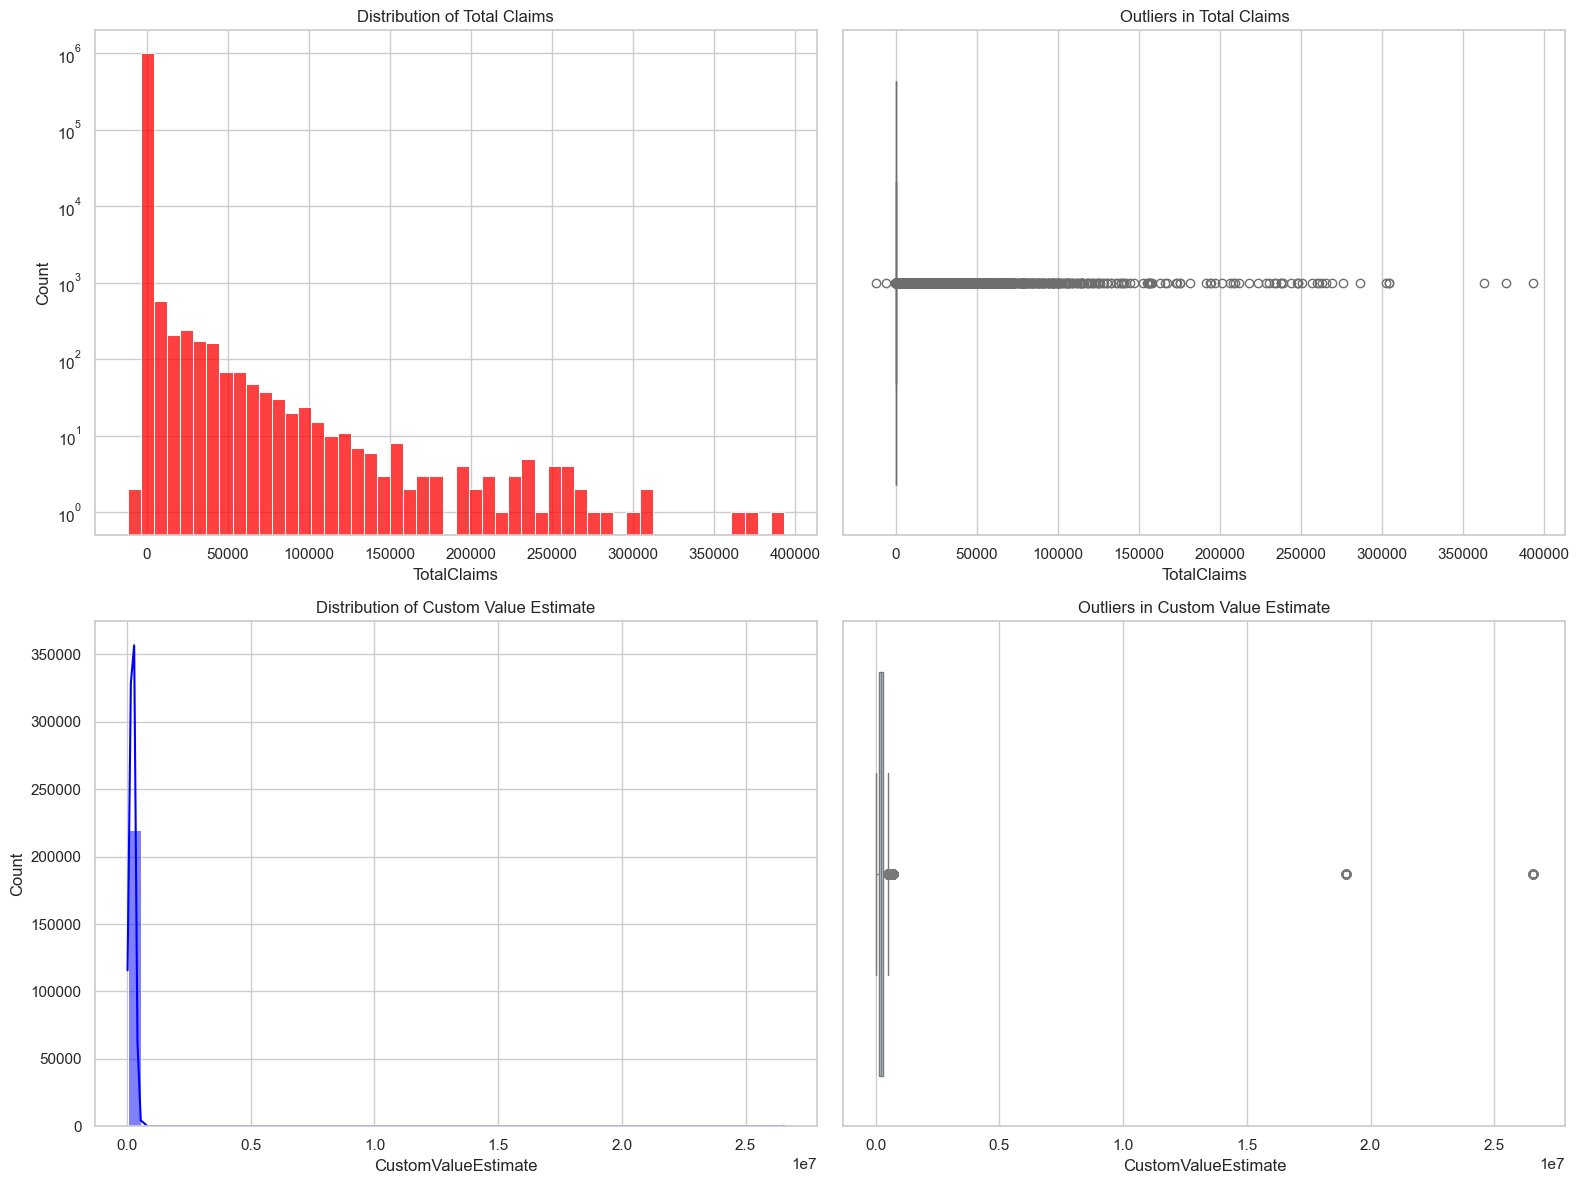

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Histogram for Total Claims
sns.histplot(df['TotalClaims'], bins=50, kde=False, color='red', ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Total Claims')
axes[0, 0].set_yscale('log') # Log scale helps us see spread when most claims are $0

# 2. Boxplot for Total Claims (Spots Outliers)
sns.boxplot(x=df['TotalClaims'], color='lightcoral', ax=axes[0, 1])
axes[0, 1].set_title('Outliers in Total Claims')

# 3. Histogram for Custom Value Estimate
sns.histplot(df['CustomValueEstimate'], bins=50, kde=True, color='blue', ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Custom Value Estimate')

# 4. Boxplot for Custom Value Estimate (Spots Outliers)
sns.boxplot(x=df['CustomValueEstimate'], color='lightblue', ax=axes[1, 1])
axes[1, 1].set_title('Outliers in Custom Value Estimate')

plt.tight_layout()
plt.show()

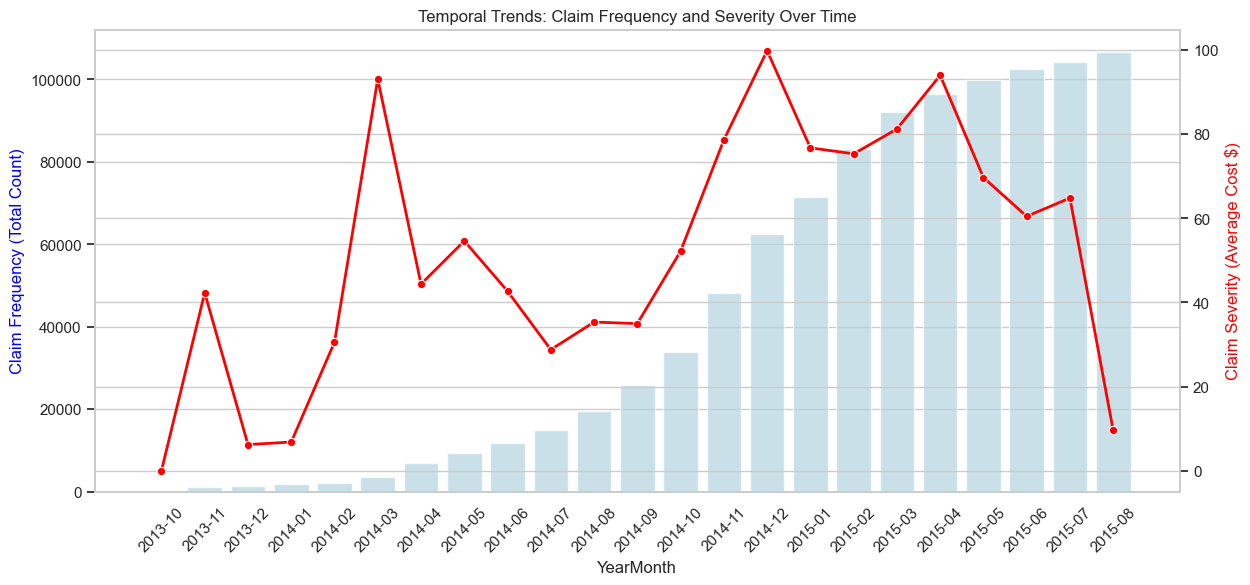

In [17]:
# IMPORTANT: Change 'TransactionMonth' if your date column has a different name!
date_col = 'TransactionMonth' 

# Convert the column to actual datetime objects
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

# Extract just the Year and Month (e.g., '2015-01') for clean grouping
df['YearMonth'] = df[date_col].dt.to_period('M').astype(str)

# Calculate Frequency (count of claims) and Severity (average claim cost)
trends = df.groupby('YearMonth')['TotalClaims'].agg(
    Frequency='count', 
    Severity='mean'
).reset_index()

# Plotting the dual-axis chart
fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar chart for Frequency
sns.barplot(data=trends, x='YearMonth', y='Frequency', color='lightblue', ax=ax1, alpha=0.7)
ax1.set_ylabel('Claim Frequency (Total Count)', color='blue')
ax1.tick_params(axis='x', rotation=45)

# Line chart for Severity (using ax1.twinx() to share the same X-axis)
ax2 = ax1.twinx()
sns.lineplot(data=trends, x='YearMonth', y='Severity', color='red', marker='o', ax=ax2, linewidth=2)
ax2.set_ylabel('Claim Severity (Average Cost $)', color='red')

plt.title('Temporal Trends: Claim Frequency and Severity Over Time')
plt.show()

In [18]:
# Isolate only the rows where a claim was actually filed (TotalClaims > 0)
claims_only = df[df['TotalClaims'] > 0]

# Calculate the average claim cost AND the total number of claims per car Make
# (We use the 'make' column based on your previous fix)
vehicle_risk = claims_only.groupby('make')['TotalClaims'].agg(['mean', 'count'])

# Filter out rare cars (less than 10 claims) so one bad crash doesn't skew the data
vehicle_risk = vehicle_risk[vehicle_risk['count'] >= 10]

# Sort to find the highest and lowest averages
highest_risk = vehicle_risk.sort_values(by='mean', ascending=False).head(5)
lowest_risk = vehicle_risk.sort_values(by='mean', ascending=True).head(5)

print("=== TOP 5 MOST EXPENSIVE VEHICLE MAKES TO INSURE ===")
display(highest_risk)

print("\n=== TOP 5 CHEAPEST VEHICLE MAKES TO INSURE ===")
display(lowest_risk)

=== TOP 5 MOST EXPENSIVE VEHICLE MAKES TO INSURE ===


,mean,count
make,,
GOLDEN JOURNEY,46169.723522,27
IVECO,31495.539656,24
AUDI,30939.506443,33
VOLKSWAGEN,30150.485741,61
CMC,30082.171180,44



=== TOP 5 CHEAPEST VEHICLE MAKES TO INSURE ===


,mean,count
make,,
JINBEI,15490.435805,22
BMW,19259.886014,25
NISSAN/DATSUN,21974.968008,17
TOYOTA,22331.508098,2318
MERCEDES-BENZ,22960.559974,128


In [3]:
import pandas as pd
import os

print("Loading data safely...")
# Step 1: Step UP one folder from 'notebooks' to find the 'data' folder
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir) 
data_path = os.path.join(parent_dir, 'data', 'MachineLearningRating_v3_cleaned.txt')

# Step 2: Use 'usecols' to only load the exact columns we need for this math
columns_needed = ['TotalPremium', 'TotalClaims', 'Province', 'Gender', 'VehicleType']
df = pd.read_csv(data_path, sep='|', usecols=columns_needed)
print("Data loaded successfully! (Memory saved)\n")

# Step 3: Run the calculations
# Calculate Overall Loss Ratio
total_premium = df['TotalPremium'].sum()
total_claims = df['TotalClaims'].sum()
overall_loss_ratio = total_claims / total_premium
print(f"Overall Loss Ratio: {overall_loss_ratio:.4f} ({(overall_loss_ratio*100):.2f}%)")

# Calculate Loss Ratio by Province
print("\n--- Loss Ratio by Province ---")
prov_group = df.groupby('Province')[['TotalPremium', 'TotalClaims']].sum()
prov_group['LossRatio'] = prov_group['TotalClaims'] / prov_group['TotalPremium']
print(prov_group.sort_values(by='LossRatio', ascending=False)['LossRatio'])

# Calculate Loss Ratio by Gender
print("\n--- Loss Ratio by Gender ---")
gender_group = df.groupby('Gender')[['TotalPremium', 'TotalClaims']].sum()
gender_group['LossRatio'] = gender_group['TotalClaims'] / gender_group['TotalPremium']
print(gender_group.sort_values(by='LossRatio', ascending=False)['LossRatio'])

# Calculate Loss Ratio by Vehicle Type
print("\n--- Loss Ratio by Vehicle Type ---")
veh_group = df.groupby('VehicleType')[['TotalPremium', 'TotalClaims']].sum()
veh_group['LossRatio'] = veh_group['TotalClaims'] / veh_group['TotalPremium']
print(veh_group.sort_values(by='LossRatio', ascending=False)['LossRatio'])

Loading data safely...
Data loaded successfully! (Memory saved)

Overall Loss Ratio: 1.0477 (104.77%)

--- Loss Ratio by Province ---
Province
Gauteng          1.222018
KwaZulu-Natal    1.082693
Western Cape     1.059472
North West       0.790367
Mpumalanga       0.720897
Free State       0.680758
Limpopo          0.661199
Eastern Cape     0.633813
Northern Cape    0.282699
Name: LossRatio, dtype: float64

--- Loss Ratio by Gender ---
Gender
Not specified    1.059311
Male             0.883910
Female           0.821879
Name: LossRatio, dtype: float64

--- Loss Ratio by Vehicle Type ---
VehicleType
Heavy Commercial     1.628112
Medium Commercial    1.050251
Passenger Vehicle    1.048198
Light Commercial     0.232066
Bus                  0.137292
Name: LossRatio, dtype: float64


Loading data for outlier analysis safely...
--- Statistical Distribution ---
       CustomValueEstimate  TotalPremium   TotalClaims
count         2.204560e+05  1.000098e+06  1.000098e+06
mean          2.255311e+05  6.190550e+01  6.486119e+01
std           5.645157e+05  2.302845e+02  2.384075e+03
min           2.000000e+04 -7.825768e+02 -1.200241e+04
25%           1.350000e+05  0.000000e+00  0.000000e+00
50%           2.200000e+05  2.178333e+00  0.000000e+00
75%           2.800000e+05  2.192982e+01  0.000000e+00
max           2.655000e+07  6.528260e+04  3.930921e+05


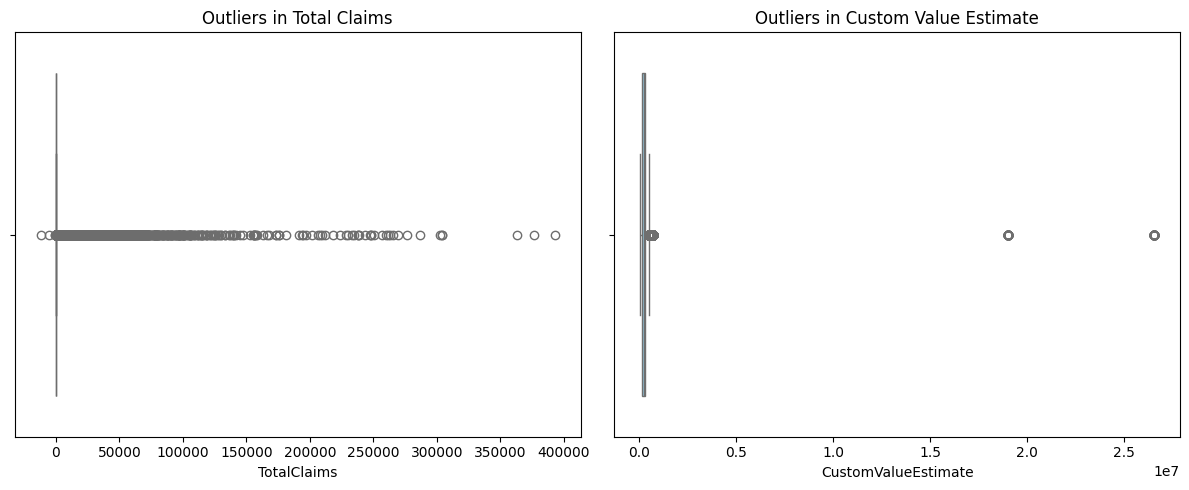

In [5]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

print("Loading data for outlier analysis safely...")
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir) 
data_path = os.path.join(parent_dir, 'data', 'MachineLearningRating_v3_cleaned.txt')

# Use 'usecols' again to grab only what we need for this specific chart
columns_needed = ['TotalPremium', 'TotalClaims', 'CustomValueEstimate']
df_outliers = pd.read_csv(data_path, sep='|', usecols=columns_needed)

# View statistical spread
print("--- Statistical Distribution ---")
print(df_outliers.describe())

# Plot boxplots to visually spot outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x=df_outliers['TotalClaims'], ax=axes[0], color='salmon')
axes[0].set_title('Outliers in Total Claims')

sns.boxplot(x=df_outliers['CustomValueEstimate'], ax=axes[1], color='skyblue')
axes[1].set_title('Outliers in Custom Value Estimate')

plt.tight_layout()
plt.show()

Loading data for temporal trends safely...
--- Temporal Trends (Frequency and Severity) ---
                  Claim_Frequency  Avg_Severity
TransactionMonth                               
2013-10                  0.000000           NaN
2013-11                  0.001672  25292.539474
2013-12                  0.002007   3094.461988
2014-01                  0.001095   6218.429825
2014-02                  0.002910  10498.217836
2014-03                  0.003462  26898.751798
2014-04                  0.002891  15343.179605
2014-05                  0.002952  18501.526310
2014-06                  0.002368  18019.157018
2014-07                  0.001811  15888.230403
2014-08                  0.002599  13596.464912
2014-09                  0.001847  18935.467694
2014-10                  0.002750  18975.194895
2014-11                  0.003710  21196.900015
2014-12                  0.003298  30278.995646
2015-01                  0.003493  21978.094542
2015-02                  0.003450  21838.511

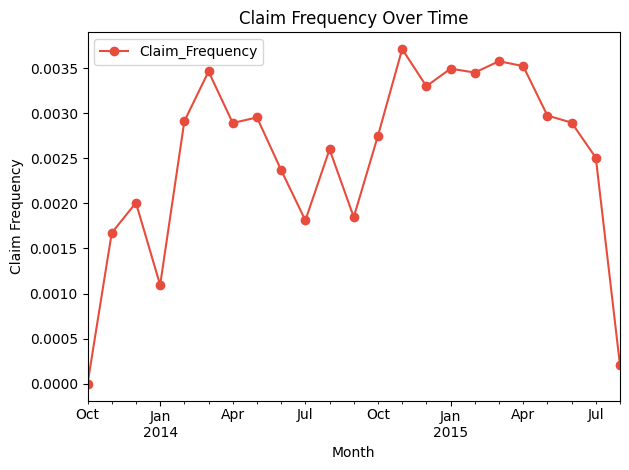

In [7]:
import pandas as pd
import os
import matplotlib.pyplot as plt

print("Loading data for temporal trends safely...")
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir) 
data_path = os.path.join(parent_dir, 'data', 'MachineLearningRating_v3_cleaned.txt')

# Load only the columns needed for the timeline math
columns_needed = ['TransactionMonth', 'PolicyID', 'TotalClaims']
df_temporal = pd.read_csv(data_path, sep='|', usecols=columns_needed)

# Ensure TransactionMonth is a datetime object
df_temporal['TransactionMonth'] = pd.to_datetime(df_temporal['TransactionMonth'])

# Group by month and calculate frequency and severity
monthly_trends = df_temporal.groupby(df_temporal['TransactionMonth'].dt.to_period('M')).agg(
    PolicyCount=('PolicyID', 'count'),
    TotalClaims_Sum=('TotalClaims', 'sum'),
    Claims_Occurred=('TotalClaims', lambda x: (x > 0).sum()) # Count how many > 0
)

# Calculate Frequency and Average Severity per month
monthly_trends['Claim_Frequency'] = monthly_trends['Claims_Occurred'] / monthly_trends['PolicyCount']
monthly_trends['Avg_Severity'] = monthly_trends['TotalClaims_Sum'] / monthly_trends['Claims_Occurred']

print("--- Temporal Trends (Frequency and Severity) ---")
print(monthly_trends[['Claim_Frequency', 'Avg_Severity']])

# Plot the trends
monthly_trends[['Claim_Frequency']].plot(kind='line', title='Claim Frequency Over Time', marker='o', color='#e74c3c')
plt.ylabel('Claim Frequency')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

In [9]:
import pandas as pd
import os

print("Loading data for vehicle make analysis safely...")
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir) 
data_path = os.path.join(parent_dir, 'data', 'MachineLearningRating_v3_cleaned.txt')

# Load exactly what we need. 
# (If it throws an error again, change 'make' to 'Make'!)
columns_needed = ['make', 'TotalClaims']
df_vehicles = pd.read_csv(data_path, sep='|', usecols=columns_needed)

# Filter to only look at policies that actually had a claim > 0
df_claims_only = df_vehicles[df_vehicles['TotalClaims'] > 0]

# Group by make and calculate the average claim severity
make_severity = df_claims_only.groupby('make')['TotalClaims'].mean().sort_values(ascending=False)

print("--- Top 5 Vehicle Makes with HIGHEST Avg Claims ---")
print(make_severity.head(5))

print("\n--- Top 5 Vehicle Makes with LOWEST Avg Claims ---")
print(make_severity.tail(5))

Loading data for vehicle make analysis safely...
--- Top 5 Vehicle Makes with HIGHEST Avg Claims ---
make
POLARSUN                               125197.843333
HYUNDAI                                 56663.492325
B.A.W                                   47856.245614
GOLDEN JOURNEY                          46169.723522
MERCEDES-BENZ                           34079.340852
Name: TotalClaims, dtype: float64

--- Top 5 Vehicle Makes with LOWEST Avg Claims ---
make
TOYOTA                                 8969.587719
CHEVROLET                              8222.473684
MARCOPOLO                              7996.535088
MITSUBISHI                             2378.596491
FORD                                   2040.473684
Name: TotalClaims, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_776\3913937148.py:44: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_776\3913937148.py:44: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_776\3913937148.py:44: UserWarning: Glyph 128188 (\N{BRIEFCASE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_776\3913937148.py:45: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.savefig('../reports/risk_matrix.png', dpi=300)
C:\Users\HP\AppData\Local\Temp\ipykernel_776\3913937148.py:45: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.savefig('../reports/risk_matrix.png', dpi=300)
C:\Users\HP\AppData\Local\Temp\ipykernel_776\3913937148.py:45: UserWarning: Glyph 128188 (\N{BRIEFCASE}) missing from font(s) Arial.
  plt.sav

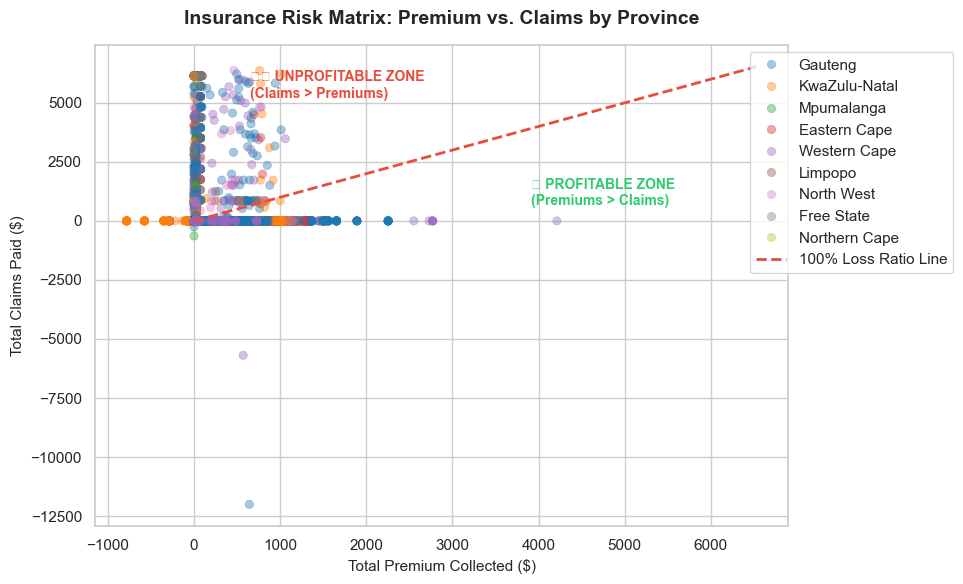

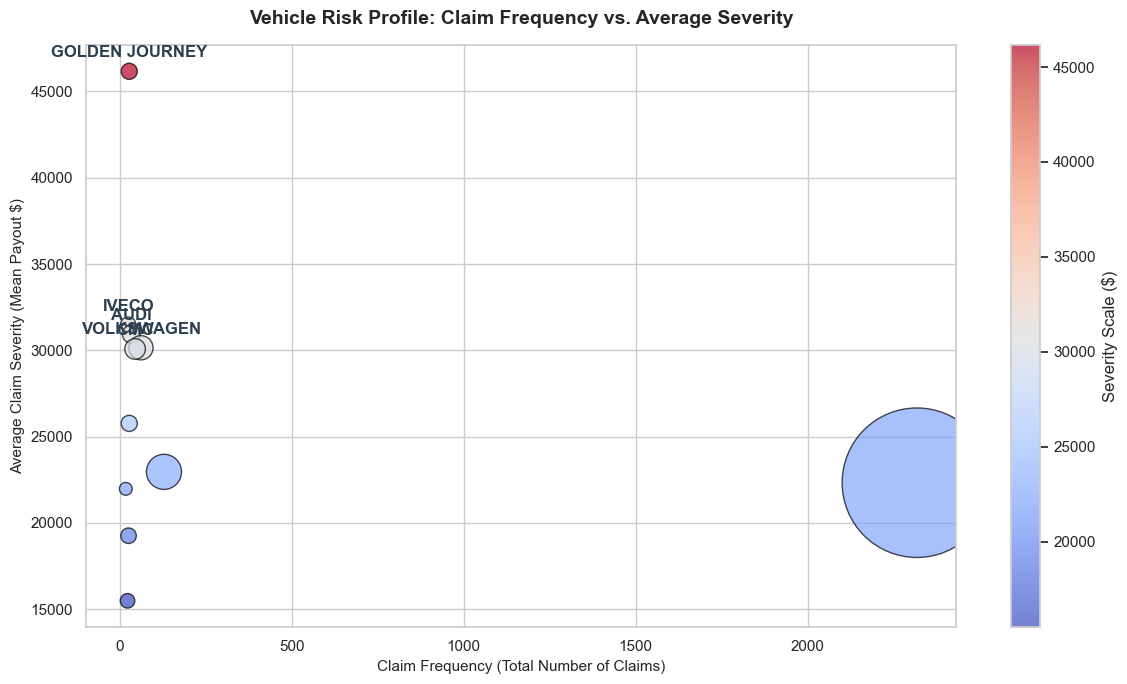

C:\Users\HP\AppData\Local\Temp\ipykernel_776\3913937148.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


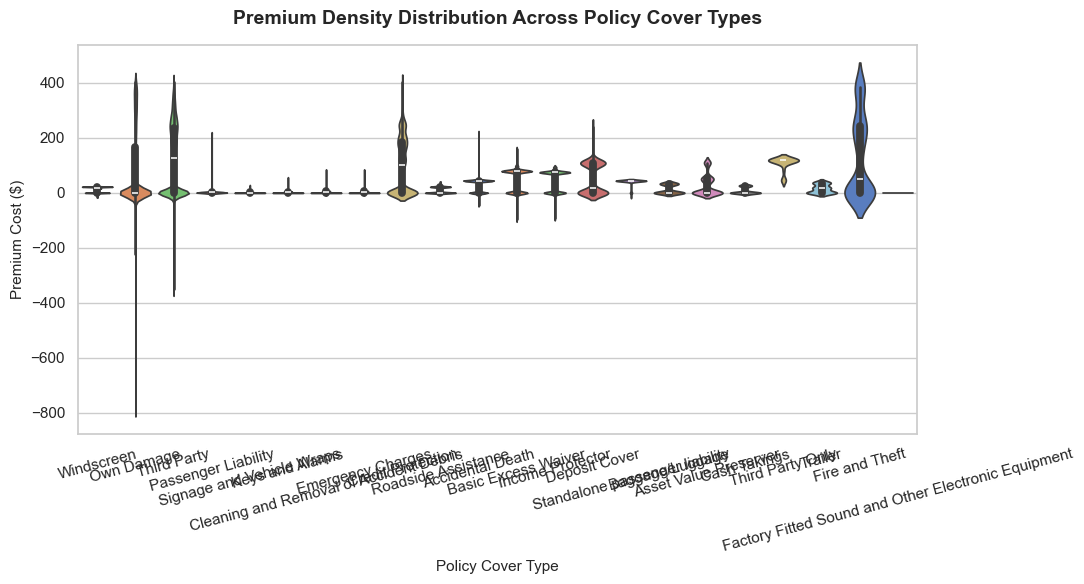

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the visual style matches a clean, modern analytics framework
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.titlesize'] = 16

# Filter out zero-claim data where necessary to avoid squeezing scales
claims_df = df[df['TotalClaims'] > 0]

# ==========================================
# PLOT 1: THE BREAK-EVEN RISK MATRIX
# ==========================================
plt.figure(figsize=(10, 6))

# Define the maximum value to draw a perfect 45-degree break-even line
max_val = min(df['TotalPremium'].max(), df['TotalClaims'].max()) * 0.1 # scaled for visibility

# Scatter plot comparing premium vs claims layered by Province
sns.scatterplot(
    data=df[(df['TotalPremium'] < max_val) & (df['TotalClaims'] < max_val)], 
    x='TotalPremium', 
    y='TotalClaims', 
    hue='Province', 
    alpha=0.4, 
    palette='tab10',
    edgecolor=None
)

# Draw the 100% Loss Ratio Line (Break-even line)
plt.plot([0, max_val], [0, max_val], color='#e74c3c', linestyle='--', linewidth=2, label='100% Loss Ratio Line')

# Text annotations to show profitable vs unprofitable zones
plt.text(max_val * 0.1, max_val * 0.8, '⚠️ UNPROFITABLE ZONE\n(Claims > Premiums)', color='#e74c3c', fontweight='bold', fontsize=10)
plt.text(max_val * 0.6, max_val * 0.1, '💼 PROFITABLE ZONE\n(Premiums > Claims)', color='#2ecc71', fontweight='bold', fontsize=10)

plt.title('Insurance Risk Matrix: Premium vs. Claims by Province', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Total Premium Collected ($)', fontsize=11)
plt.ylabel('Total Claims Paid ($)', fontsize=11)
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
plt.tight_layout()
plt.savefig('../reports/risk_matrix.png', dpi=300)
plt.show()


# ==========================================
# PLOT 2: VEHICLE RISK BUBBLE CHART
# ==========================================
# Aggregate metrics per car brand
vehicle_stats = claims_df.groupby('make')['TotalClaims'].agg(['mean', 'count']).reset_index()
# Filter for statistically significant brands
vehicle_stats = vehicle_stats[vehicle_stats['count'] >= 15].sort_values(by='mean', ascending=False)

plt.figure(figsize=(12, 7))

# Create bubble chart: X=Frequency, Y=Severity, Size=Volume of claims
bubble = plt.scatter(
    x=vehicle_stats['count'], 
    y=vehicle_stats['mean'], 
    s=vehicle_stats['count'] * 5, # Size scaling
    c=vehicle_stats['mean'],       # Color mapping
    cmap='coolwarm', 
    alpha=0.7, 
    edgecolors='black', 
    linewidth=1
)

# Label top high-risk vehicle makes dynamically
for i, txt in enumerate(vehicle_stats['make'].head(5)):
    plt.annotate(txt, (vehicle_stats['count'].iloc[i], vehicle_stats['mean'].iloc[i]), 
                 textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold', color='#2c3e50')

plt.title('Vehicle Risk Profile: Claim Frequency vs. Average Severity', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Claim Frequency (Total Number of Claims)', fontsize=11)
plt.ylabel('Average Claim Severity (Mean Payout $)', fontsize=11)
plt.colorbar(bubble, label='Severity Scale ($)')
plt.tight_layout()
plt.savefig('../reports/vehicle_bubble_chart.png', dpi=300)
plt.show()


# ==========================================
# PLOT 3: DENSITY DISTRIBUTION OF COVER TYPES
# ==========================================
plt.figure(figsize=(11, 6))

# Violin plot with inner boxplot to show distribution density clean and clearly
sns.violinplot(
    data=df[df['TotalPremium'] < df['TotalPremium'].quantile(0.95)], # Exclude extreme outliers for visualization
    x='CoverType', 
    y='TotalPremium', 
    palette='muted', 
    inner='box'
)

plt.title('Premium Density Distribution Across Policy Cover Types', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Policy Cover Type', fontsize=11)
plt.ylabel('Premium Cost ($)', fontsize=11)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../reports/cover_type_density.png', dpi=300)
plt.show()